# b) Use random forest to predict house prices for the dataset you used in exercise1

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../data/data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [43]:
df_cleaned = df.drop(["date", "street", "city", "statezip", "country", "condition", "waterfront", "floors"], axis="columns")#, "condition", "waterfront", "floors"], axis="columns")#"sqft_lot", "condition", "yr_built", "yr_renovated"
df_cleaned.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,view,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,0,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,4,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,0,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,0,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,0,1140,800,1976,1992


In [44]:
df_cleaned["yr_renovated"] = df_cleaned.apply(
    lambda row: row["yr_built"] if not row["yr_renovated"] else row["yr_renovated"], axis=1
)
df_cleaned.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,view,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,0,1340,0,1955,2005.0
1,2384000.0,5.0,2.50,3650,9050,4,3370,280,1921,1921.0
2,342000.0,3.0,2.00,1930,11947,0,1930,0,1966,1966.0
3,420000.0,3.0,2.25,2000,8030,0,1000,1000,1963,1963.0
4,550000.0,4.0,2.50,1940,10500,0,1140,800,1976,1992.0


In [45]:
lower_limit = df_cleaned["price"].quantile(0.01)
upper_limit = df_cleaned["price"].quantile(0.99)

df_no_outliers = df_cleaned[(df_cleaned["price"] >= lower_limit) & (df_cleaned["price"] <= upper_limit)]

print(f"rows after filtering: {df_no_outliers.shape[0]} rows")
print(f"lower : {lower_limit:,.0f}  |  upper: {upper_limit:,.0f}")

rows after filtering: 4554 rows
lower : 0  |  upper: 2,005,220


In [46]:
X, y = df_no_outliers.drop("price", axis=1), df_no_outliers["price"]

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,view,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.0,1.50,1340,7912,0,1340,0,1955,2005.0
2,3.0,2.00,1930,11947,0,1930,0,1966,1966.0
3,3.0,2.25,2000,8030,0,1000,1000,1963,1963.0
4,4.0,2.50,1940,10500,0,1140,800,1976,1992.0
5,2.0,1.00,880,6380,0,880,0,1938,1994.0


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((3051, 9), (1503, 9))

In [48]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42) # 2?
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


         Feature  Importance
2    sqft_living    0.497444
7       yr_built    0.109860
3       sqft_lot    0.109568
5     sqft_above    0.079263
8   yr_renovated    0.056552
1      bathrooms    0.050937
4           view    0.040390
6  sqft_basement    0.029430
0       bedrooms    0.026556


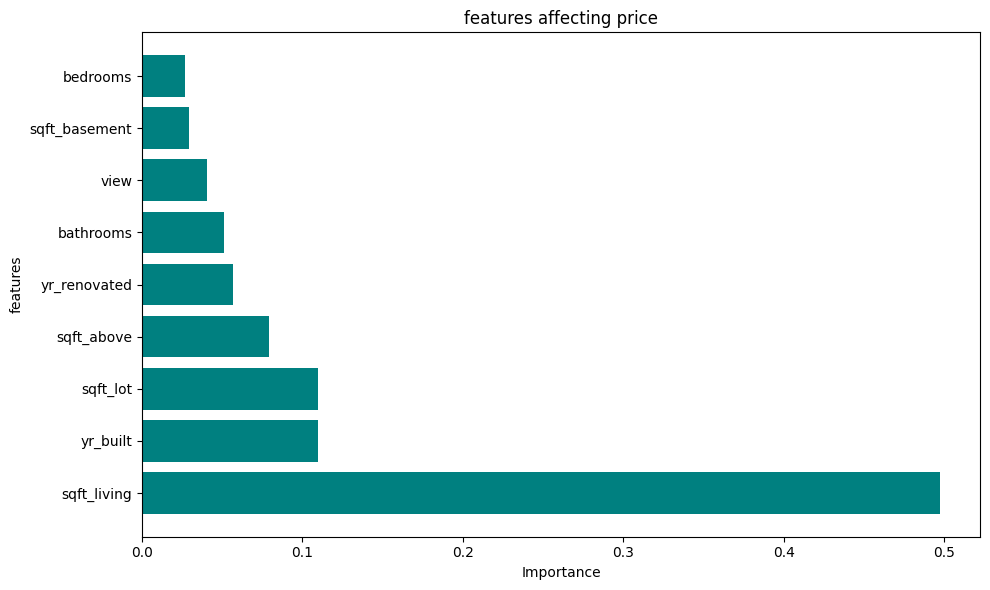

In [49]:
importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel("Importance")
plt.ylabel("features")
plt.title("features affecting price")
plt.tight_layout()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 150214.64
MSE: 46482848464.20
RMSE: 215598.81
R²: 0.46


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# copilot 
# Funktion som ritar grafen för vald feature
def plot_rf_feature(feature_name):
    
    feature_index = list(X.columns).index(feature_name)
    X_feature = X.iloc[:, feature_index].values.reshape(-1, 1)

    # Skapa grid för vald feature
    X_grid = np.linspace(X_feature.min(), X_feature.max(), 200).reshape(-1, 1)

    # Fyll övriga features med medelvärden
    X_full_grid = np.tile(X_train.mean().values, (X_grid.shape[0], 1))
    X_full_grid[:, feature_index] = X_grid[:, 0]
    X_full_grid_df = pd.DataFrame(X_full_grid, columns=X_train.columns)

    # Prediktioner
    y_grid_pred = model.predict(X_full_grid_df)

    # Rita grafen
    plt.figure(figsize=(10, 6))
    plt.scatter(X_feature, y, color='blue', alpha=0.4, label="Faktiska data")
    plt.plot(X_grid, y_grid_pred, color='green', linewidth=2, label="Random Forest-prediktion")
    plt.title(f"Random Forest Regression – Pris vs. {feature_name}", fontsize=16)
    plt.xlabel(feature_name)
    plt.ylabel("Pris")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Skapa dropdown med alla features
feature_dropdown = widgets.Dropdown(
    options=list(X.columns),
    value="sqft_living",  # startvärde
    description="Feature:"
)

# Koppla interaktiv funktion
interact(plot_rf_feature, feature_name=feature_dropdown)

interactive(children=(Dropdown(description='Feature:', index=2, options=('bedrooms', 'bathrooms', 'sqft_living…

<function __main__.plot_rf_feature(feature_name)>